Loading dataset: C:\Users\Administrator\Desktop\Rutile-DS-1.xlsx
Loaded dataset shape: (3149, 29)
Dataset columns: ['Sample ID', 'Mg', 'Al', 'Si', 'S', 'Ca', 'Sc', 'V', 'Cr', 'Fe', 'Ni', 'Cu', 'Zn', 'Y', 'Zr', 'Nb', 'Mo', 'Sn', 'Sb', 'Hf', 'Ta', 'W', 'Pb', 'Bi', 'Th', 'U', 'Calibrated T(℃)', 'Host Lithology', 'Location']
Dataset shape: (3149, 29)

Using 24 trace elements as features:
  Features: ['Mg', 'Al', 'Si', 'S', 'Ca', 'Sc', 'V', 'Cr', 'Fe', 'Ni', 'Cu', 'Zn', 'Y', 'Nb', 'Mo', 'Sn', 'Sb', 'Hf', 'Ta', 'W', 'Pb', 'Bi', 'Th', 'U']

Temperature Category Distribution:
  Low-T (<600°C): 788 samples (25.0%)
  Mid-T (600-800°C): 2157 samples (68.5%)
  High-T (800-1000°C): 164 samples (5.2%)
  Very High-T (>1000°C): 40 samples (1.3%)

Training Set Distribution:
  Low-T (<600°C): 630 (25.0%)
  Mid-T (600-800°C): 1726 (68.5%)
  High-T (800-1000°C): 131 (5.2%)
  Very High-T (>1000°C): 32 (1.3%)

Test Set Distribution:
  Low-T (<600°C): 158 (25.1%)
  Mid-T (600-800°C): 431 (68.4%)
  High-T (80

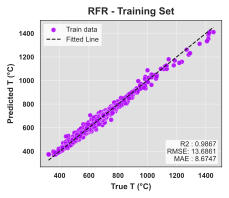

Figure saved: C:\Users\Administrator\Desktop\Codes\Zr-excluded (DS1)\Figures\RFR_True_vs_Pred_Test.svg


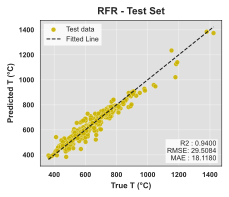

Figure saved: C:\Users\Administrator\Desktop\Codes\Zr-excluded (DS1)\Figures\RFR_(Train)_Residuals_vs_Predicted.svg


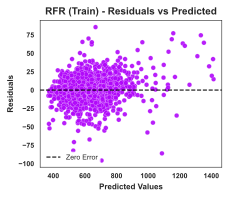

Figure saved: C:\Users\Administrator\Desktop\Codes\Zr-excluded (DS1)\Figures\RFR_(Train)_Residual_Distribution.svg


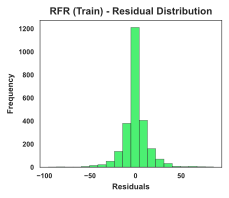


RFR (Train) - Residual Statistics:
  Mean : 0.1731
  Std  : 13.6850
  Min  : -95.7490
  Max  : 85.6391
Figure saved: C:\Users\Administrator\Desktop\Codes\Zr-excluded (DS1)\Figures\RFR_(Test)_Residuals_vs_Predicted.svg


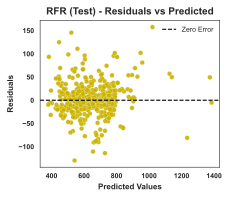

Figure saved: C:\Users\Administrator\Desktop\Codes\Zr-excluded (DS1)\Figures\RFR_(Test)_Residual_Distribution.svg


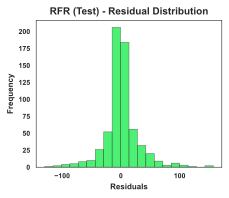


RFR (Test) - Residual Statistics:
  Mean : 1.4711
  Std  : 29.4718
  Min  : -129.8145
  Max  : 157.4802
Figure saved: C:\Users\Administrator\Desktop\Codes\Zr-excluded (DS1)\Figures\RFR_Feature_Importance_Top10.svg


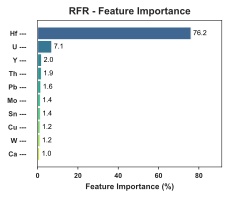


RFR - Top 10 Feature Importance:
--------------------------------------------------
   1. Hf  :  76.16% (raw: 0.761604)
   2. U   :   7.07% (raw: 0.070676)
   3. Y   :   2.02% (raw: 0.020160)
   4. Th  :   1.89% (raw: 0.018938)
   5. Pb  :   1.63% (raw: 0.016324)
   6. Mo  :   1.36% (raw: 0.013644)
   7. Sn  :   1.35% (raw: 0.013528)
   8. Cu  :   1.24% (raw: 0.012397)
   9. W   :   1.21% (raw: 0.012051)
  10. Ca  :   1.03% (raw: 0.010289)
--------------------------------------------------

GENERATING PARTIAL DEPENDENCE PLOTS FOR RFR

Figure saved: C:\Users\Administrator\Desktop\Codes\Zr-excluded (DS1)\Figures\RFR_PDP_Hf.svg


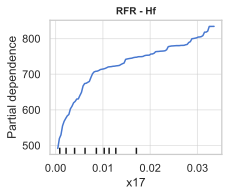

Figure saved: C:\Users\Administrator\Desktop\Codes\Zr-excluded (DS1)\Figures\RFR_PDP_U.svg


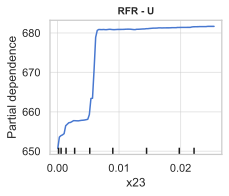

Figure saved: C:\Users\Administrator\Desktop\Codes\Zr-excluded (DS1)\Figures\RFR_PDP_Th.svg


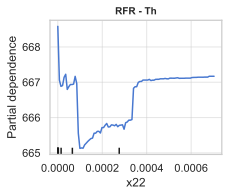

Figure saved: C:\Users\Administrator\Desktop\Codes\Zr-excluded (DS1)\Figures\RFR_PDP_Nb.svg


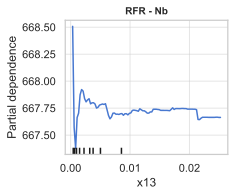


Random Forest model training and evaluation complete.
All outputs saved to: C:\Users\Administrator\Desktop\Codes\Zr-excluded (DS1)


In [1]:
import pandas as pd
import numpy as np
from joblib import dump
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.font_manager import FontProperties
from matplotlib_inline.backend_inline import set_matplotlib_formats
import warnings
import os

set_matplotlib_formats('svg')
warnings.filterwarnings('ignore')

FONT_FAMILY             = 'Arial'
TITLE_FONT_SIZE         = 14
TITLE_FONT_WEIGHT       = 'bold'
LABEL_FONT_SIZE         = 12
TICK_FONT_SIZE          = 10
VALUE_FONT_SIZE         = 10
LEGEND_FONT_SIZE        = 10

GLOBAL_FONT_SIZE        = 10
FIGURE_DPI              = 120
AXES_LINE_WIDTH         = 0.8
GRID_COLOR              = '#CCCCCC'
GRID_ALPHA              = 0.5
SNS_STYLE               = 'whitegrid'
SNS_PALETTE             = 'muted'
SNS_FONT_SCALE          = 1.0

TRUE_PRED_SCATTER_FIGSIZE       = (3.35, 2.91)
RESIDUAL_ANALYSIS_TRAIN_FIGSIZE = (3.35, 2.91)
RESIDUAL_ANALYSIS_TEST_FIGSIZE  = (3.35, 2.91)
FEATURE_IMPORTANCE_FIGSIZE      = (3.35, 2.91)
PDP_GRID_FIGSIZE                = (14, 10)

PDP_SELECTED_FEATURES   = ['Hf', 'U', 'Th', 'Nb']
PDP_LINE_COLOR          = '#2E86AB'
PDP_LINE_WIDTH          = 2.5

SCATTER_TRAIN_COLOR     = '#b107fa'
SCATTER_TEST_COLOR      = '#CBB300'
SCATTER_SIZE            = 36
SCATTER_ALPHA           = 0.9
SCATTER_EDGE_WIDTH      = 0.2

TRUE_PRED_SCATTER_POINT_SIZE   = 22
TRUE_PRED_SCATTER_TITLE_SIZE   = 10
TRUE_PRED_SCATTER_LABEL_SIZE   = 8
TRUE_PRED_SCATTER_LABEL_WEIGHT = 'bold'
TRUE_PRED_SCATTER_TICK_SIZE    = 7
TRUE_PRED_SCATTER_VALUE_SIZE   = 7
TRUE_PRED_SCATTER_LEGEND_SIZE  = 7
TRUE_PRED_SCATTER_LINE_WIDTH   = 1.0
TRUE_PRED_SCATTER_TICK_LENGTH  = 2.5
TRUE_PRED_SCATTER_TICK_WIDTH   = 0.6

RESIDUAL_HIST_BINS       = 20
RESIDUAL_HIST_COLOR      = '#00E936'
RESIDUAL_HIST_ALPHA      = 0.7
RESIDUAL_HIST_EDGE_COLOR = 'black'
RESIDUAL_HIST_EDGE_WIDTH = 0.4
ZERO_LINE_COLOR          = 'black'
ZERO_LINE_STYLE          = '--'
ZERO_LINE_WIDTH          = 1.1

RESIDUAL_POINT_SIZE      = 22
RESIDUAL_TITLE_SIZE      = 10
RESIDUAL_LABEL_SIZE      = 8
RESIDUAL_LABEL_WEIGHT    = 'bold'
RESIDUAL_TICK_SIZE       = 7
RESIDUAL_LEGEND_SIZE     = 7
RESIDUAL_TICK_LENGTH     = 2.5
RESIDUAL_TICK_WIDTH      = 0.6

FEATURE_IMPORTANCE_BAR_HEIGHT     = 0.95
FEATURE_IMPORTANCE_BAR_ALPHA      = 0.95
FEATURE_IMPORTANCE_BAR_EDGE_COLOR = 'white'
FEATURE_IMPORTANCE_BAR_EDGE_WIDTH = 1
FEATURE_IMPORTANCE_COLORMAP       = 'viridis'
FEATURE_IMPORTANCE_CMAP_LOW       = 0.9
FEATURE_IMPORTANCE_CMAP_HIGH      = 0.3
FEATURE_IMPORTANCE_TOP_N          = 10
FEATURE_IMPORTANCE_XLIM_SCALE     = 1.2
FEATURE_IMPORTANCE_VALUE_OFFSET   = 1
FEATURE_IMPORTANCE_TITLE_SIZE     = 10
FEATURE_IMPORTANCE_TITLE_WEIGHT   = 'bold'
FEATURE_IMPORTANCE_LABEL_SIZE     = 8
FEATURE_IMPORTANCE_LABEL_WEIGHT   = 'bold'
FEATURE_IMPORTANCE_TICK_SIZE      = 7
FEATURE_IMPORTANCE_VALUE_SIZE     = 7
FEATURE_IMPORTANCE_TICK_LENGTH    = 2.5
FEATURE_IMPORTANCE_TICK_WIDTH     = 0.6

TICK_DIRECTION    = 'out'
TICK_LENGTH       = 3.5
TICK_WIDTH        = 0.8
TICK_COLOR        = 'black'
X_NBINS           = 6
Y_NBINS           = 6
BORDER_LINE_WIDTH = 0.5
BORDER_COLOR      = 'black'

plt.rc('font', family=FONT_FAMILY)
plt.rcParams['font.size']      = GLOBAL_FONT_SIZE
plt.rcParams['figure.dpi']     = FIGURE_DPI
plt.rcParams['axes.linewidth'] = AXES_LINE_WIDTH
plt.rcParams['grid.color']     = GRID_COLOR
plt.rcParams['grid.alpha']     = GRID_ALPHA
sns.set(style=SNS_STYLE, palette=SNS_PALETTE, font_scale=SNS_FONT_SCALE)

title_font  = FontProperties(family=FONT_FAMILY, size=TITLE_FONT_SIZE,  weight=TITLE_FONT_WEIGHT)
label_font  = FontProperties(family=FONT_FAMILY, size=LABEL_FONT_SIZE)
tick_font   = FontProperties(family=FONT_FAMILY, size=TICK_FONT_SIZE)
value_font  = FontProperties(family=FONT_FAMILY, size=VALUE_FONT_SIZE)
legend_font = FontProperties(family=FONT_FAMILY, size=LEGEND_FONT_SIZE)

RANDOM_STATE = 18
TEST_SIZE    = 0.2
DATASET_PATH = r'C:\Users\Administrator\Desktop\Rutile-DS-1.xlsx'
OUTPUT_DIR   = r'C:\Users\Administrator\Desktop\Codes\Zr-excluded (DS1)'
DATASET_NAME = 'Zr-excluded (DS1)'
FIGURES_DIR  = os.path.join(OUTPUT_DIR, 'Figures')

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
if not os.path.exists(FIGURES_DIR):
    os.makedirs(FIGURES_DIR)

def save_figure(fig, figure_name):
    filepath = os.path.join(FIGURES_DIR, f"{figure_name}.svg")
    fig.savefig(filepath, format='svg', bbox_inches='tight', dpi=FIGURE_DPI)
    print(f"Figure saved: {filepath}")

def add_plot_borders(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(BORDER_LINE_WIDTH)
        spine.set_edgecolor(BORDER_COLOR)

def preprocess_data(df, test_size=TEST_SIZE, random_state=RANDOM_STATE):
    print("Dataset columns:", df.columns.tolist())
    print("Dataset shape:", df.shape)
    
    target_column = 'Calibrated T(℃)'
    
    if target_column not in df.columns:
        print(f"Error: Target '{target_column}' not found!")
        print("Available columns:", df.columns.tolist())
        return None

    columns_to_drop = [target_column, 'Zr', 'Sample ID', 'Host Lithology', 'Location']
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [col for col in numeric_cols if col not in columns_to_drop]
    
    print(f"\nUsing {len(feature_cols)} trace elements as features:")
    print(f"  Features: {feature_cols}")
    
    x = df[feature_cols]
    y = df[target_column]

    bins       = [y.min(), 600, 800, 1000, y.max()]
    bin_labels = ['Low-T (<600\u00b0C)', 'Mid-T (600-800\u00b0C)',
                  'High-T (800-1000\u00b0C)', 'Very High-T (>1000\u00b0C)']
    y_categories = pd.cut(y, bins=bins, labels=bin_labels, include_lowest=True)

    print("\nTemperature Category Distribution:")
    for cat, cnt in y_categories.value_counts().sort_index().items():
        print(f"  {cat}: {cnt} samples ({cnt/len(y)*100:.1f}%)")

    xtrain, xtest, ytrain, ytest = train_test_split(
        x, y, test_size=test_size, random_state=random_state, stratify=y_categories)

    print("\nTraining Set Distribution:")
    for cat in bin_labels:
        n = (pd.cut(ytrain, bins=bins, labels=bin_labels, include_lowest=True) == cat).sum()
        print(f"  {cat}: {n} ({n/len(ytrain)*100:.1f}%)")

    print("\nTest Set Distribution:")
    for cat in bin_labels:
        n = (pd.cut(ytest, bins=bins, labels=bin_labels, include_lowest=True) == cat).sum()
        print(f"  {cat}: {n} ({n/len(ytest)*100:.1f}%)")

    high_T_train = (ytrain > 1000).sum()
    high_T_test  = (ytest  > 1000).sum()
    print(f"\nHigh-T Samples (>1000\u00b0C) in Train: {high_T_train} ({high_T_train/len(ytrain)*100:.1f}%)")
    print(f"High-T Samples (>1000\u00b0C) in Test:  {high_T_test}  ({high_T_test/len(ytest)*100:.1f}%)")

    scaler        = MinMaxScaler()
    xtrain_scaled = scaler.fit_transform(xtrain)
    xtest_scaled  = scaler.transform(xtest)

    return (xtrain_scaled, xtest_scaled, ytrain, ytest,
            xtrain.columns.tolist(), xtrain.values, xtest.values, scaler)

def calculate_metrics(y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f"  R2   : {r2:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    return r2, rmse, mae

def save_best_model(model, model_name, dataset_name):
    model_path = os.path.join(OUTPUT_DIR, f"{model_name}_{dataset_name}.pkl")
    dump(model, model_path)
    print(f"Best model saved to: {model_path}")
    return model_path

def plot_true_vs_pred_scatter(y_train, y_train_pred, y_test, y_test_pred,
                               train_metrics, test_metrics, model_name="Model"):
    _title_fp  = FontProperties(family=FONT_FAMILY, size=TRUE_PRED_SCATTER_TITLE_SIZE,
                                 weight=TITLE_FONT_WEIGHT)
    _label_fp  = FontProperties(family=FONT_FAMILY, size=TRUE_PRED_SCATTER_LABEL_SIZE,
                                 weight=TRUE_PRED_SCATTER_LABEL_WEIGHT)
    _legend_fp = FontProperties(family=FONT_FAMILY, size=TRUE_PRED_SCATTER_LEGEND_SIZE)
    _value_fp  = FontProperties(family=FONT_FAMILY, size=TRUE_PRED_SCATTER_VALUE_SIZE)
    _tick_fp   = FontProperties(family=FONT_FAMILY, size=TRUE_PRED_SCATTER_TICK_SIZE,
                                 weight='bold')

    def _draw(ax, y_true, y_pred, color, label, title, metrics):
        r2, rmse, mae = metrics
        ax.set_facecolor("#e0e0e0")
        ax.grid(color="white", linewidth=0.6)
        ax.scatter(y_true, y_pred, s=TRUE_PRED_SCATTER_POINT_SIZE, color=color,
                   alpha=SCATTER_ALPHA, edgecolor='#FFFFFF',
                   linewidth=SCATTER_EDGE_WIDTH, label=label)
        lo = min(y_true.min(), y_pred.min())
        hi = max(y_true.max(), y_pred.max())
        ax.plot([lo, hi], [lo, hi], 'k--',
                linewidth=TRUE_PRED_SCATTER_LINE_WIDTH, label='Fitted Line')
        ax.set_title(title, fontproperties=_title_fp)
        ax.set_xlabel("True T (\u00b0C)", fontproperties=_label_fp)
        ax.set_ylabel("Predicted T (\u00b0C)", fontproperties=_label_fp)
        ax.tick_params(labelsize=TRUE_PRED_SCATTER_TICK_SIZE, direction=TICK_DIRECTION,
                       length=TRUE_PRED_SCATTER_TICK_LENGTH,
                       width=TRUE_PRED_SCATTER_TICK_WIDTH, color=TICK_COLOR)
        for lbl in ax.get_xticklabels(): lbl.set_fontproperties(_tick_fp)
        for lbl in ax.get_yticklabels(): lbl.set_fontproperties(_tick_fp)
        leg = ax.legend(frameon=True, fancybox=False, loc='upper left', prop=_legend_fp)
        leg.get_frame().set_edgecolor('none')
        leg.get_frame().set_linewidth(0.0)
        leg.get_frame().set_facecolor('white')
        txt = f"R2 : {r2:.4f}\nRMSE: {rmse:.4f}\nMAE : {mae:.4f}"
        ax.text(0.97, 0.03, txt, transform=ax.transAxes,
                fontsize=TRUE_PRED_SCATTER_VALUE_SIZE, va='bottom', ha='right',
                bbox=dict(boxstyle='square,pad=0.20', facecolor='white',
                          edgecolor='none', alpha=0.8),
                fontproperties=_value_fp)
        add_plot_borders(ax)

    fig, ax = plt.subplots(figsize=TRUE_PRED_SCATTER_FIGSIZE)
    _draw(ax, y_train, y_train_pred, SCATTER_TRAIN_COLOR,
          'Train data', f"{model_name} - Training Set", train_metrics)
    plt.tight_layout()
    save_figure(fig, f"{model_name}_True_vs_Pred_Train")
    plt.show()

    fig, ax = plt.subplots(figsize=TRUE_PRED_SCATTER_FIGSIZE)
    _draw(ax, y_test, y_test_pred, SCATTER_TEST_COLOR,
          'Test data', f"{model_name} - Test Set", test_metrics)
    plt.tight_layout()
    save_figure(fig, f"{model_name}_True_vs_Pred_Test")
    plt.show()

def _residual_scatter_ax(ax, y_pred, residuals, color):
    _label_fp  = FontProperties(family=FONT_FAMILY, size=RESIDUAL_LABEL_SIZE,
                                 weight=RESIDUAL_LABEL_WEIGHT)
    _legend_fp = FontProperties(family=FONT_FAMILY, size=RESIDUAL_LEGEND_SIZE)
    _tick_fp   = FontProperties(family=FONT_FAMILY, size=RESIDUAL_TICK_SIZE, weight='bold')
    ax.set_facecolor("white")
    ax.grid(color="white", linewidth=0.6)
    ax.scatter(y_pred, residuals, s=RESIDUAL_POINT_SIZE, color=color,
               alpha=SCATTER_ALPHA, edgecolor='#FFFFFF', linewidth=SCATTER_EDGE_WIDTH)
    ax.axhline(0, color=ZERO_LINE_COLOR, linestyle=ZERO_LINE_STYLE,
               linewidth=ZERO_LINE_WIDTH, label='Zero Error', zorder=7)
    ax.set_xlabel("Predicted Values", fontproperties=_label_fp)
    ax.set_ylabel("Residuals",        fontproperties=_label_fp)
    ax.tick_params(labelsize=RESIDUAL_TICK_SIZE, direction=TICK_DIRECTION,
                   length=RESIDUAL_TICK_LENGTH, width=RESIDUAL_TICK_WIDTH, color=TICK_COLOR)
    for lbl in ax.get_xticklabels(): lbl.set_fontproperties(_tick_fp)
    for lbl in ax.get_yticklabels(): lbl.set_fontproperties(_tick_fp)
    leg = ax.legend(prop=_legend_fp, frameon=True, fancybox=False)
    leg.get_frame().set_edgecolor('none')
    leg.get_frame().set_facecolor('white')
    ax.grid(True, color="white", linewidth=0.6)
    add_plot_borders(ax)

def _residual_hist_ax(ax, residuals):
    _label_fp = FontProperties(family=FONT_FAMILY, size=RESIDUAL_LABEL_SIZE,
                                weight=RESIDUAL_LABEL_WEIGHT)
    _tick_fp  = FontProperties(family=FONT_FAMILY, size=RESIDUAL_TICK_SIZE, weight='bold')
    ax.set_facecolor("white")
    ax.hist(residuals, bins=RESIDUAL_HIST_BINS, color=RESIDUAL_HIST_COLOR,
            alpha=RESIDUAL_HIST_ALPHA, edgecolor=RESIDUAL_HIST_EDGE_COLOR,
            linewidth=RESIDUAL_HIST_EDGE_WIDTH)
    ax.set_xlabel("Residuals", fontproperties=_label_fp)
    ax.set_ylabel("Frequency", fontproperties=_label_fp)
    ax.tick_params(labelsize=RESIDUAL_TICK_SIZE, direction=TICK_DIRECTION,
                   length=RESIDUAL_TICK_LENGTH, width=RESIDUAL_TICK_WIDTH, color=TICK_COLOR)
    for lbl in ax.get_xticklabels(): lbl.set_fontproperties(_tick_fp)
    for lbl in ax.get_yticklabels(): lbl.set_fontproperties(_tick_fp)
    ax.locator_params(axis='x', nbins=X_NBINS)
    ax.grid(True, color="white", linewidth=0.6)
    add_plot_borders(ax)

def plot_residual_analysis(y_true, y_pred, model_name):
    residuals = y_true.values - y_pred
    color     = SCATTER_TRAIN_COLOR if "Train" in model_name else SCATTER_TEST_COLOR
    figsize   = RESIDUAL_ANALYSIS_TRAIN_FIGSIZE if "Train" in model_name \
                else RESIDUAL_ANALYSIS_TEST_FIGSIZE
    _title_fp = FontProperties(family=FONT_FAMILY, size=RESIDUAL_TITLE_SIZE,
                               weight=TITLE_FONT_WEIGHT)

    fig_scatter, ax_scatter = plt.subplots(figsize=figsize)
    ax_scatter.set_title(f"{model_name} - Residuals vs Predicted",
                         fontproperties=_title_fp)
    _residual_scatter_ax(ax_scatter, y_pred, residuals, color)
    plt.tight_layout()
    save_figure(fig_scatter, f"{model_name.replace(' ', '_')}_Residuals_vs_Predicted")
    plt.show()

    fig_hist, ax_hist = plt.subplots(figsize=figsize)
    ax_hist.set_title(f"{model_name} - Residual Distribution", fontproperties=_title_fp)
    _residual_hist_ax(ax_hist, residuals)
    plt.tight_layout()
    save_figure(fig_hist, f"{model_name.replace(' ', '_')}_Residual_Distribution")
    plt.show()

    print(f"\n{model_name} - Residual Statistics:")
    print(f"  Mean : {np.mean(residuals):.4f}")
    print(f"  Std  : {np.std(residuals):.4f}")
    print(f"  Min  : {np.min(residuals):.4f}")
    print(f"  Max  : {np.max(residuals):.4f}")

def plot_feature_importance(model, feature_names, model_name,
                             top_n=FEATURE_IMPORTANCE_TOP_N):
    importance     = model.feature_importances_
    importance_pct = (importance / importance.sum()) * 100
    indices        = np.argsort(importance_pct)[-top_n:]

    _title_fp = FontProperties(family=FONT_FAMILY, size=FEATURE_IMPORTANCE_TITLE_SIZE,
                                weight=FEATURE_IMPORTANCE_TITLE_WEIGHT)
    _label_fp = FontProperties(family=FONT_FAMILY, size=FEATURE_IMPORTANCE_LABEL_SIZE,
                                weight=FEATURE_IMPORTANCE_LABEL_WEIGHT)
    _tick_fp  = FontProperties(family=FONT_FAMILY, size=FEATURE_IMPORTANCE_TICK_SIZE,
                                weight='bold')
    _value_fp = FontProperties(family=FONT_FAMILY, size=FEATURE_IMPORTANCE_VALUE_SIZE)

    cmap   = plt.cm.get_cmap(FEATURE_IMPORTANCE_COLORMAP)
    colors = cmap(np.linspace(FEATURE_IMPORTANCE_CMAP_LOW,
                              FEATURE_IMPORTANCE_CMAP_HIGH, len(indices)))

    fig, ax = plt.subplots(figsize=FEATURE_IMPORTANCE_FIGSIZE)
    ax.set_facecolor("white")
    bars = ax.barh(range(len(indices)), importance_pct[indices], color=colors,
                   edgecolor=FEATURE_IMPORTANCE_BAR_EDGE_COLOR,
                   linewidth=FEATURE_IMPORTANCE_BAR_EDGE_WIDTH,
                   alpha=FEATURE_IMPORTANCE_BAR_ALPHA,
                   height=FEATURE_IMPORTANCE_BAR_HEIGHT)

    for i, bar in enumerate(bars):
        val = importance_pct[indices[i]]
        ax.text(val + FEATURE_IMPORTANCE_VALUE_OFFSET,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}', ha='left', va='center',
                fontproperties=_value_fp, color='black')

    feature_labels = [f"{feature_names[i]} --- " for i in indices]
    ax.set_yticks(range(len(indices)))
    ax.set_yticklabels(feature_labels, fontproperties=_tick_fp)
    ax.set_xlabel("Feature Importance (%)", fontproperties=_label_fp)
    ax.set_title(f"{model_name} - Feature Importance", fontproperties=_title_fp)
    ax.set_xlim(0, importance_pct[indices].max() * FEATURE_IMPORTANCE_XLIM_SCALE)
    for lbl in ax.get_xticklabels(): lbl.set_fontproperties(_tick_fp)
    ax.grid(False)
    ax.tick_params(axis='x', which='major', direction=TICK_DIRECTION,
                   length=FEATURE_IMPORTANCE_TICK_LENGTH,
                   width=FEATURE_IMPORTANCE_TICK_WIDTH,
                   color=TICK_COLOR, bottom=True, top=False)
    ax.tick_params(axis='y', left=False)
    add_plot_borders(ax)
    fig.subplots_adjust(left=0.25, right=0.95, top=0.90, bottom=0.15)
    plt.tight_layout()
    save_figure(fig, f"{model_name}_Feature_Importance_Top{top_n}")
    plt.show()

    print(f"\n{model_name} - Top {top_n} Feature Importance:")
    print("-" * 50)
    for rank, idx in enumerate(indices[::-1], 1):
        print(f"  {rank:2d}. {feature_names[idx]:4s}: "
              f"{importance_pct[idx]:6.2f}% (raw: {importance[idx]:.6f})")
    print("-" * 50)

def plot_partial_dependence(model, X_train, feature_names, model_name="Model"):
    print(f"\n{'='*70}")
    print(f"GENERATING PARTIAL DEPENDENCE PLOTS FOR {model_name}")
    print(f"{'='*70}\n")

    _title_fp = FontProperties(family=FONT_FAMILY, size=TRUE_PRED_SCATTER_TITLE_SIZE,
                                weight=TITLE_FONT_WEIGHT)
    _label_fp = FontProperties(family=FONT_FAMILY, size=TRUE_PRED_SCATTER_LABEL_SIZE,
                                weight=TRUE_PRED_SCATTER_LABEL_WEIGHT)
    _tick_fp  = FontProperties(family=FONT_FAMILY, size=TRUE_PRED_SCATTER_TICK_SIZE,
                                weight='bold')

    for feature_name in PDP_SELECTED_FEATURES:
        if feature_name not in feature_names:
            print(f"  WARNING: '{feature_name}' not found — skipping.")
            continue

        feature_index = feature_names.index(feature_name)
        fig, ax = plt.subplots(figsize=TRUE_PRED_SCATTER_FIGSIZE)

        from sklearn.inspection import PartialDependenceDisplay
        PartialDependenceDisplay.from_estimator(
            model, X_train, features=[feature_index], ax=ax
        )

        for line in ax.get_lines():
            line.set_color('black')
            line.set_linewidth(TRUE_PRED_SCATTER_LINE_WIDTH)

        ax.grid(False)

        ax.set_title(f"{model_name} - {feature_name}", fontproperties=_title_fp)
        ax.set_xlabel(feature_name,         fontproperties=_label_fp)
        ax.set_ylabel("Partial Dependence", fontproperties=_label_fp)
        ax.tick_params(labelsize=TRUE_PRED_SCATTER_TICK_SIZE,
                       direction=TICK_DIRECTION,
                       length=TRUE_PRED_SCATTER_TICK_LENGTH,
                       width=TRUE_PRED_SCATTER_TICK_WIDTH,
                       color=TICK_COLOR)
        for lbl in ax.get_xticklabels(): lbl.set_fontproperties(_tick_fp)
        for lbl in ax.get_yticklabels(): lbl.set_fontproperties(_tick_fp)

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(BORDER_LINE_WIDTH)
            spine.set_edgecolor('black')
            spine.set_color('black')

        plt.tight_layout()
        save_figure(fig, f"{model_name}_PDP_{feature_name}")
        plt.show()

def train_and_save_best_rfr_model(xtrain, ytrain, dataset_name):
    print("\n--- Training Random Forest Regressor ---")
    param_grid = {'n_estimators': [200], 'max_depth': [10], 'min_samples_split': [2],
                  'min_samples_leaf': [2], 'max_features': [0.8]}
    rfr = RandomForestRegressor(random_state=RANDOM_STATE)
    grid_search = GridSearchCV(rfr, param_grid, cv=5,
                               scoring='neg_mean_squared_error', n_jobs=1)
    grid_search.fit(xtrain, ytrain)
    best = grid_search.best_estimator_
    save_best_model(best, 'RFR', dataset_name)
    print(f"\nBest parameters: {grid_search.best_params_}")
    return best

def main():
    try:
        print(f"Loading dataset: {DATASET_PATH}")
        df = pd.read_excel(DATASET_PATH)
        print(f"Loaded dataset shape: {df.shape}")
    except FileNotFoundError:
        print(f"ERROR: Dataset file not found at {DATASET_PATH}.")
        return

    preprocessed = preprocess_data(df, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    if preprocessed is None:
        return

    (x_train_scaled, x_test_scaled, y_train, y_test,
     feature_names, x_train_data_array, x_test_data_array, scaler) = preprocessed

    scaler_path = os.path.join(OUTPUT_DIR, f'Scaler_{DATASET_NAME}.pkl')
    dump(scaler, scaler_path)
    print(f"\n{'='*70}")
    print(f"SCALER SAVED: {scaler_path}")
    print(f"  Features: {feature_names}")
    print(f"{'='*70}\n")

    rfr_best = train_and_save_best_rfr_model(x_train_scaled, y_train, DATASET_NAME)
    
    print("\n" + "--- RFR TRAINING SET EVALUATION ---".center(70, '-'))
    y_train_pred_rfr  = rfr_best.predict(x_train_scaled)
    train_metrics_rfr = calculate_metrics(y_train, y_train_pred_rfr)
    
    print("\n" + "--- RFR TEST SET EVALUATION ---".center(70, '-'))
    y_test_pred_rfr   = rfr_best.predict(x_test_scaled)
    test_metrics_rfr  = calculate_metrics(y_test, y_test_pred_rfr)
    
    plot_true_vs_pred_scatter(y_train, y_train_pred_rfr, y_test, y_test_pred_rfr,
                               train_metrics_rfr, test_metrics_rfr, model_name="RFR")
    
    plot_residual_analysis(y_train, y_train_pred_rfr, "RFR (Train)")
    plot_residual_analysis(y_test,  y_test_pred_rfr,  "RFR (Test)")
    
    plot_feature_importance(rfr_best, feature_names, "RFR")
    
    plot_partial_dependence(rfr_best, x_train_scaled, feature_names, model_name="RFR")

    print("\n" + "="*70)
    print("Random Forest model training and evaluation complete.")
    print(f"All outputs saved to: {OUTPUT_DIR}")
    print("="*70)

if __name__ == "__main__":
    main()
    